In [1]:
# First import the functions we will need
import sys

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## GradientTape

- [Gradien Tape AP](https://www.tensorflow.org/api_docs/python/tf/GradientTape)

`gradient` expects `Tensor` as parameters. 

- In Tensorflow, `Tensor` is the primary programmatic data structure used to store and move data through a computational graph.
- We can think of a tensor as a `multi-dimensional array` with a `fixed data type` that is heavily optimized to run on hardware accelerators like GPUs and TPUs.
- `Tensor` is somewhat similar to the concept of Numpy array. However:
  - TensorFlow tensors can be loaded directly into GPU or TPU memory for optimized operations through parallel processing.Immutability.
  - TensorFlow tensors are `immutable`. Once a tensor is created in memory, you cannot change its elements or its size. If you modify a tensor (e.g., adding 1 to all elements), TensorFlow doesn't modify the data in place; it automatically spawns a brand-new tensor object in memory.
- Tensorflow's `Variable` is a special wrapper around a standard `Tensor`. It represents mutable state that can be modified in place using specific methods like `.assign()` or `.assign_sub()`. 

In [20]:
import tensorflow as tf

# We will define a simple quadratic function to differentiate
def f(x: tf.Tensor) -> tf.Tensor:
    return 2 * x ** 2 + 3 * x + 2

# 1. Define a variable to differentiate against
x = tf.Variable(3.0)

# 2. Record the operations
with tf.GradientTape() as tape:
    y = f(x)  # Mathematical operation
    # 3. Compute the gradient of y with respect to x
    # (The derivative of 2x^2 + 3x + 2 is 4x + 3, so at x=3.0, the gradient is 15.0)
    grad = tape.gradient(y, x) 
    print(grad.numpy())  # Output: 15.0

# warning: if we use a regular float instead of a tf.Variable, the gradient will be None because TensorFlow cannot track operations on regular Python floats.
x1 = 3.0
with tf.GradientTape() as tape:
    y1 = f(x1)
    try:
        grad = tape.gradient(y1, x1) 
        print(grad.numpy())
    except Exception as e:
        print(f"Error occurred: {e}")

15.0
Error occurred: 'float' object has no attribute 'dtype'


In the example below, we manually create a Linear Regression model and setup `loss` and `train` functions. 

In [10]:
import tensorflow as tf
from typing import Any

INITIAL_W: float = 10.0
INITIAL_B: float = 10.0

class Model:
    def __init__(self) -> None:
        # Initialize the weights as TensorFlow variables
        self.w: tf.Variable = tf.Variable(INITIAL_W)
        self.b: tf.Variable = tf.Variable(INITIAL_B)

    def __call__(self, x: tf.Tensor | float) -> tf.Tensor:
        return self.w * x + self.b

# This is similar to the MSE loss function, but we use functions from TensorFlow to ensure 
# compatibility with the gradient tape
def loss(predicted_y: tf.Tensor, target_y: tf.Tensor) -> tf.Tensor:
    return tf.reduce_mean(tf.square(predicted_y - target_y))

def train(
    model: Model, 
    inputs: tf.Tensor | float, 
    outputs: tf.Tensor, 
    learning_rate: float
) -> tf.Tensor:
    with tf.GradientTape() as t:
        current_loss = loss(model(inputs), outputs)
        
    # Extract gradient computation outside the context block to save memory
    dw, db = t.gradient(current_loss, [model.w, model.b])
    
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)
    return current_loss


### Train our model

In [11]:
# Define our input data and learning rate
xs = [-1.0, 0.0, 1.0, 2.0, 3.0, 4.0]
ys = [-3.0, -1.0, 1.0, 3.0, 5.0, 7.0]
LEARNING_RATE=0.09

# Instantiate our model
model = Model()

# Collect the history of w-values and b-values to plot later
list_w, list_b = [], []
epochs = range(50)
losses = []
for epoch in epochs:
  list_w.append(model.w.numpy())
  list_b.append(model.b.numpy())
  current_loss = train(model, xs, ys, learning_rate=LEARNING_RATE)
  losses.append(current_loss)
  print(f"Epoch {epoch:2d}: w={list_w[-1]:1.2f} b={list_b[-1]:1.2f}, "
        f"loss={current_loss:2.5f}")

Epoch  0: w=10.00 b=10.00, loss=715.66669
Epoch  1: w=-0.41 b=5.86, loss=27.47032
Epoch  2: w=-0.02 b=5.28, loss=22.43888
Epoch  3: w=0.16 b=4.69, loss=18.46284
Epoch  4: w=0.33 b=4.16, loss=15.19137
Epoch  5: w=0.49 b=3.68, loss=12.49958
Epoch  6: w=0.63 b=3.25, loss=10.28476
Epoch  7: w=0.76 b=2.85, loss=8.46238
Epoch  8: w=0.87 b=2.50, loss=6.96291
Epoch  9: w=0.98 b=2.17, loss=5.72914
Epoch 10: w=1.07 b=1.88, loss=4.71398
Epoch 11: w=1.16 b=1.61, loss=3.87870
Epoch 12: w=1.24 b=1.37, loss=3.19143
Epoch 13: w=1.31 b=1.15, loss=2.62593
Epoch 14: w=1.37 b=0.95, loss=2.16064
Epoch 15: w=1.43 b=0.77, loss=1.77779
Epoch 16: w=1.48 b=0.60, loss=1.46278
Epoch 17: w=1.53 b=0.45, loss=1.20359
Epoch 18: w=1.57 b=0.32, loss=0.99032
Epoch 19: w=1.61 b=0.20, loss=0.81484
Epoch 20: w=1.65 b=0.08, loss=0.67046
Epoch 21: w=1.68 b=-0.02, loss=0.55166
Epoch 22: w=1.71 b=-0.11, loss=0.45391
Epoch 23: w=1.74 b=-0.19, loss=0.37348
Epoch 24: w=1.76 b=-0.27, loss=0.30730
Epoch 25: w=1.79 b=-0.33, loss=0.2

### Plot our trained values over time

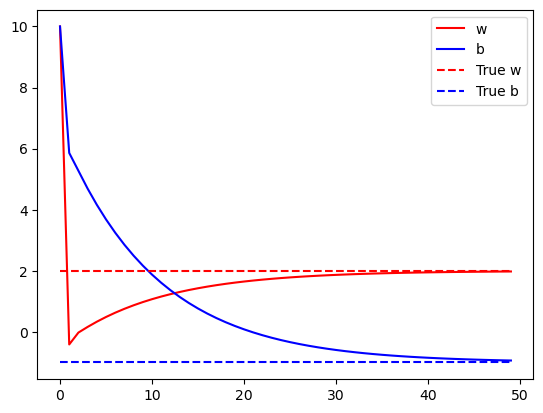

In [12]:
# Plot the w-values and b-values for each training Epoch against the true values
TRUE_w = 2.0
TRUE_b = -1.0
plt.plot(epochs, list_w, 'r', epochs, list_b, 'b')
plt.plot([TRUE_w] * len(epochs), 'r--', [TRUE_b] * len(epochs), 'b--')
plt.legend(['w', 'b', 'True w', 'True b'])
plt.show()